In [ ]:
#Load the data

In [1]:
import numpy as np

csv_path = "mtfuji_data.csv"  # Specify the file name (path)

np.set_printoptions(suppress=True)  # Set prohibition of scientific notation
fuji = np.loadtxt(csv_path, delimiter=",", skiprows=1)

In [2]:
print(fuji[130:140])

[[  130.          35.352505   138.756638  2563.4      41888.      ]
 [  131.          35.35418    138.753742  2703.1      42210.      ]
 [  132.          35.355855   138.750846  2825.55     42532.      ]
 [  133.          35.35753    138.74795   2967.9      42854.      ]
 [  134.          35.359205   138.745054  3087.81     43177.      ]
 [  135.          35.36088    138.742157  3266.24     43499.      ]
 [  136.          35.362555   138.739261  3434.59     43821.      ]
 [  137.          35.36423    138.736364  3600.08     44143.      ]
 [  138.          35.365904   138.733468  3679.96     44466.      ]
 [  139.          35.367579   138.730571  3664.9      44788.      ]]


In [3]:
print(fuji)

[[    0.          35.134141   139.132082     0.           0.      ]
 [    1.          35.135826   139.129202     0.         322.      ]
 [    2.          35.13751    139.126322     0.         644.      ]
 ...
 [  297.          35.631284   138.271368  1973.99     95698.      ]
 [  298.          35.632947   138.268452  1841.36     96020.      ]
 [  299.          35.63461    138.265536  1725.8      96343.      ]]


In [ ]:
# [Problem 1] Data visualization

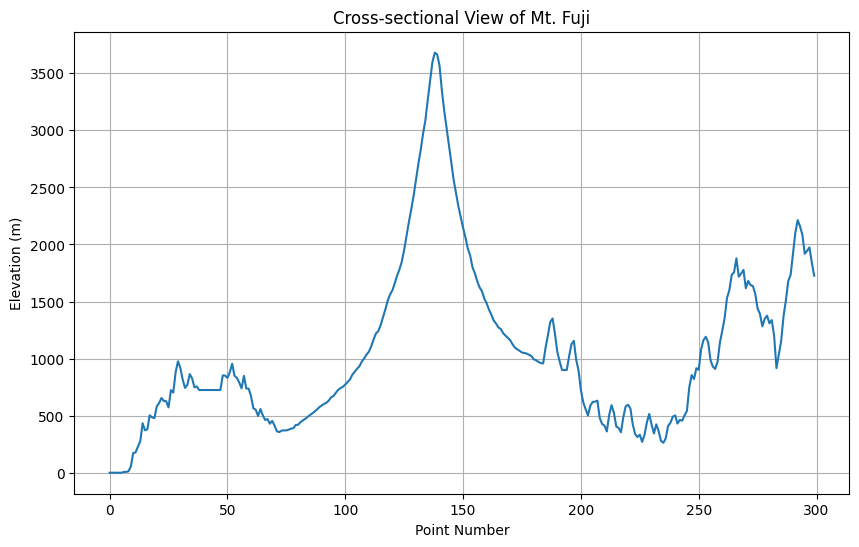

In [4]:
import matplotlib.pyplot as plt

# The point numbers are in the first column (index 0)
x_data = fuji[:, 0]

# The elevation data is in the fourth column (index 3)
y_data = fuji[:, 3]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data)
plt.title("Cross-sectional View of Mt. Fuji")
plt.xlabel("Point Number")
plt.ylabel("Elevation (m)")
plt.grid(True)
plt.show()

In [ ]:
# [Problem 2] Create a function to calculate the gradient at a certain point

In [5]:

# Load the Mt. Fuji data
csv_path = "mtfuji_data.csv"
np.set_printoptions(suppress=True)
fuji = np.loadtxt(csv_path, delimiter=",", skiprows=1)

def calculate_gradient(current_point):
  """
  Calculates the gradient (slope) at a given point on Mt. Fuji.

  Args:
    current_point (int): The number of the current point (from 1 to 299).

  Returns:
    float: The calculated gradient at that point.
  """
  # Get the elevation and point number of the current point
  x1 = fuji[current_point, 0]
  y1 = fuji[current_point, 3]

  # Get the elevation and point number of the previous point
  # We use current_point - 1 to get the preceding data point
  x2 = fuji[current_point - 1, 0]
  y2 = fuji[current_point - 1, 3]

  # Calculate the gradient using the formula
  gradient = (y1 - y2) / (x1 - x2)

  return gradient

# Example usage: Calculate the gradient at point 135
# This point is near the summit, where the slope should be steep
point_number = 135
slope = calculate_gradient(point_number)
print(f"The gradient at point {point_number} is: {slope}")

The gradient at point 135 is: 178.42999999999984


In [ ]:
# [Problem 3] Create a function to calculate the destination point

In [6]:
def move_to_next_point(current_point, alpha=0.2):
    """
    Calculates the next point to move to using gradient descent.

    Args:
      current_point (int): The number of the current point.
      alpha (float): The learning rate (hyperparameter).

    Returns:
      int: The number of the next point.
    """
    # 1. Get the gradient at the current point
    gradient = calculate_gradient(current_point)

    # 2. Apply the gradient descent formula
    next_point_float = current_point - alpha * gradient

    # 3. Round the result to an integer
    next_point_integer = round(next_point_float)

    # 4. Handle invalid values (e.g., negative point numbers)
    # The valid range of points is from 0 to 299 (inclusive)
    if next_point_integer < 0:
        next_point_integer = 0
    
    return int(next_point_integer)

# Example usage:
start_point = 136  # A point near the summit
next_point = move_to_next_point(start_point, alpha=0.2)
print(f"Starting at point {start_point}, the next point is: {next_point}")

Starting at point 136, the next point is: 102


In [ ]:
# [Problem 4] Create a function to go down the mountain

In [7]:
def descend_mountain(start_point=136):
    """
    Simulates a descent down Mt. Fuji using gradient descent.

    Args:
      start_point (int): The starting point for the descent.

    Returns:
      list: A list of all points visited during the descent.
    """
    path = [start_point]
    current_point = start_point
    
    while True:
        next_point = move_to_next_point(current_point)
        
        # Check if we have stopped moving (reached a flat area)
        if next_point == current_point:
            break
        
        path.append(next_point)
        current_point = next_point
        
        # Add a safeguard to prevent infinite loops, though not expected
        if len(path) > 300: 
            break
            
    return path

# Example usage:
descent_path = descend_mountain(start_point=136)
print("The path of descent is:", descent_path)
print(f"The total number of steps taken is: {len(descent_path)}")

The path of descent is: [136, 102, 98, 95, 93, 89, 85, 82, 79, 73, 70, 78, 77, 75]
The total number of steps taken is: 14


In [ ]:
# [Problem 5] Visualization of the descent process

In [11]:
def run_descent_simulation(start_point, alpha=0.2):
    """
    Runs the full descent simulation and visualizes the results.

    Args:
        start_point (int): The starting point for the descent.
        alpha (float): The learning rate.
    """
    # Get the descent path
    descent_path_points = descend_mountain(start_point)

    # Extract elevations for the descent path
    descent_elevations = [fuji[int(p), 3] for p in descent_path_points]

    # Calculate gradients for the descent path
    descent_gradients = [calculate_gradient(int(p)) for p in descent_path_points]

    # --- Visualization 1: Descent Path on the Mountain Cross-Section ---
    plt.figure(figsize=(10, 6))
    plt.title(f"Descent Path from Point {start_point} on Mt. Fuji's Cross-Section")
    plt.xlabel("Point Number")
    plt.ylabel("Elevation (m)")
    plt.grid(True)

    # Plot the entire cross-section of Mt. Fuji
    plt.plot(fuji[:, 0], fuji[:, 3], label='Mt. Fuji Profile')

    # Plot the points of the descent path
    plt.scatter(descent_path_points, descent_elevations, c='red', s=50, zorder=5, label='Descent Path')

    # Add a marker for the starting point
    plt.scatter(descent_path_points[0], descent_elevations[0], c='green', s=100, marker='o', zorder=6, label='Starting Point')

    plt.legend()
    plt.show()

    # --- Visualization 2: Altitude and Gradient over Descent Steps ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    # Subplot 1: Elevation over time
    axes[0].set_title(f"Elevation at Each Step of the Descent (Start Point: {start_point})")
    axes[0].set_xlabel("Descent Step")
    axes[0].set_ylabel("Elevation (m)")
    axes[0].grid(True)
    axes[0].plot(range(len(descent_elevations)), descent_elevations, marker='o')

    # Subplot 2: Gradient over time
    axes[1].set_title(f"Gradient at Each Step of the Descent (Start Point: {start_point})")
    axes[1].set_xlabel("Descent Step")
    axes[1].set_ylabel("Gradient (slope)")
    axes[1].grid(True)
    axes[1].plot(range(len(descent_gradients)), descent_gradients, marker='o', color='red')

    plt.tight_layout()
    plt.show()

In [ ]:
# [Problem 6] Change of initial value

Running simulation starting from point 136 (near the summit)...


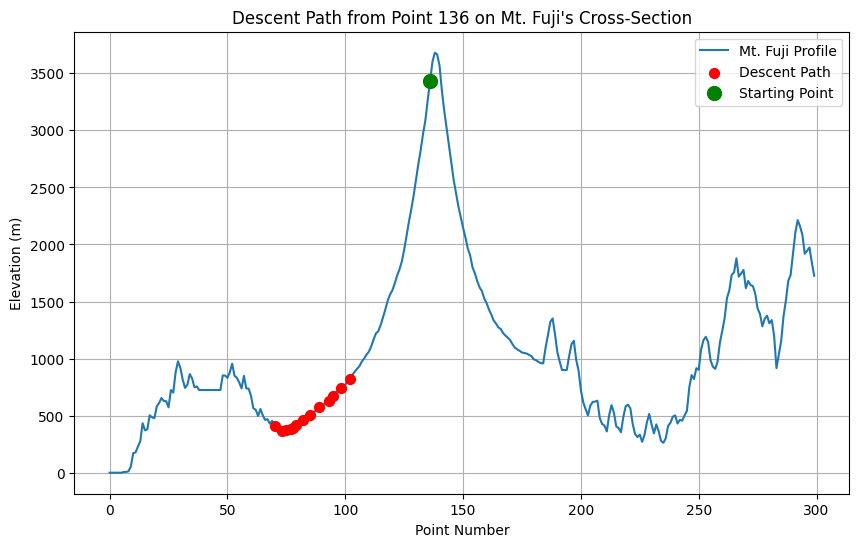

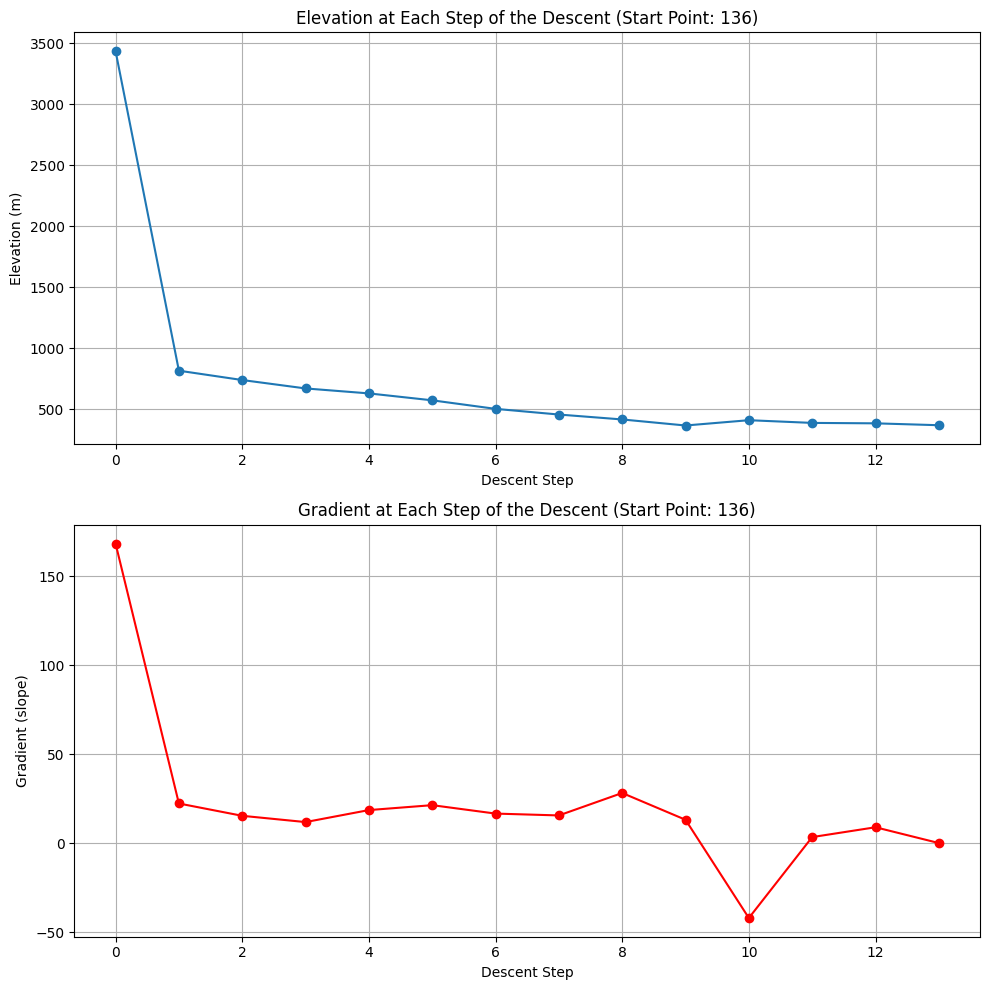


Running simulation starting from point 250...


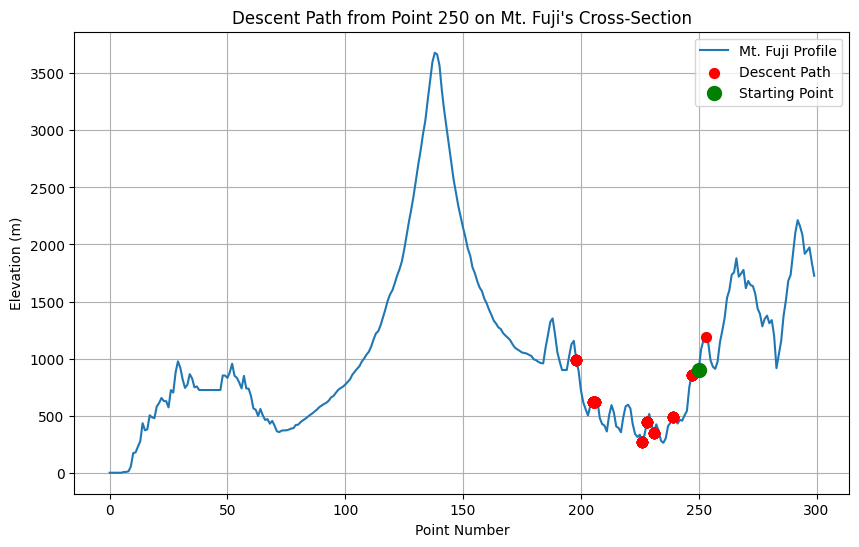

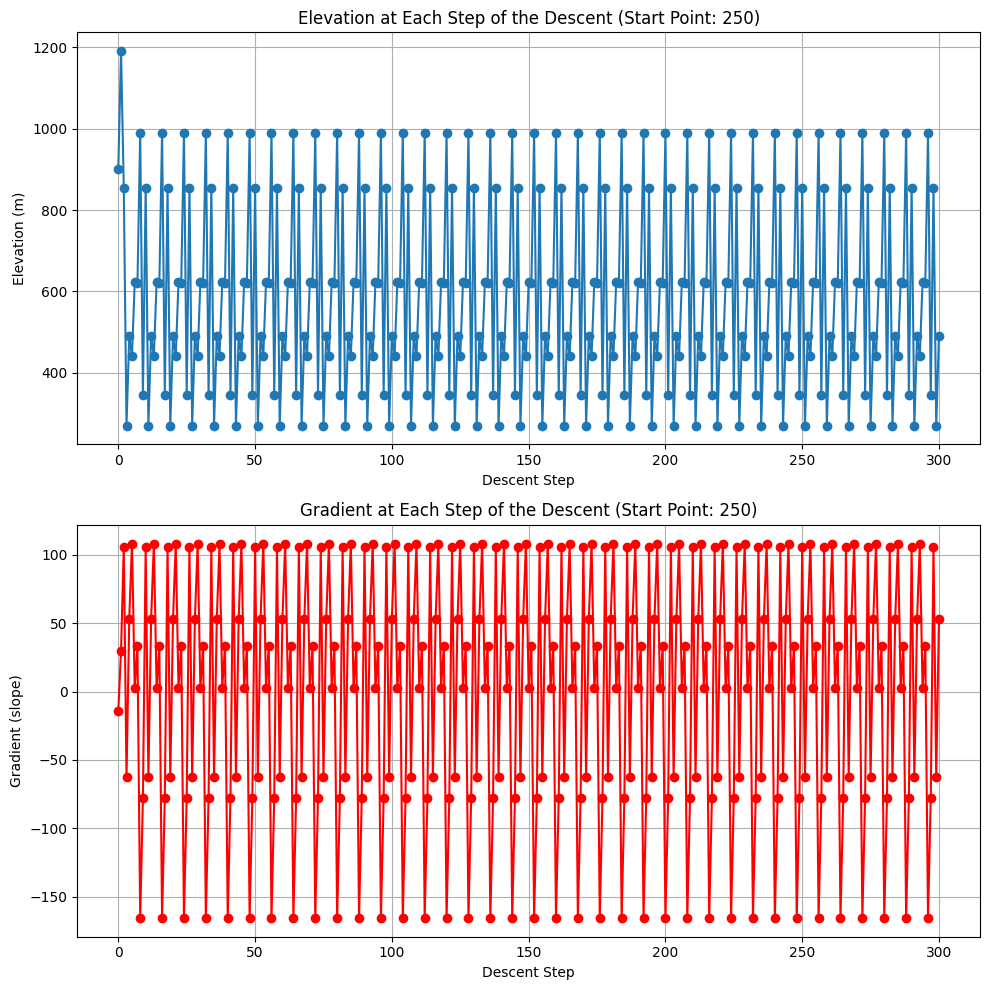

In [12]:
# The run_descent_simulation function now accepts a start_point argument
# and the descend_mountain function is called with this argument.
# ... (function definitions are above this section) ...

# This is how you change the initial value:
print("Running simulation starting from point 136 (near the summit)...")
run_descent_simulation(start_point=136)

print("\nRunning simulation starting from point 250...")
run_descent_simulation(start_point=250)

In [ ]:
# [Problem 7] Visualization of the descent process for each initial value


--- Running simulation starting from point 136 ---


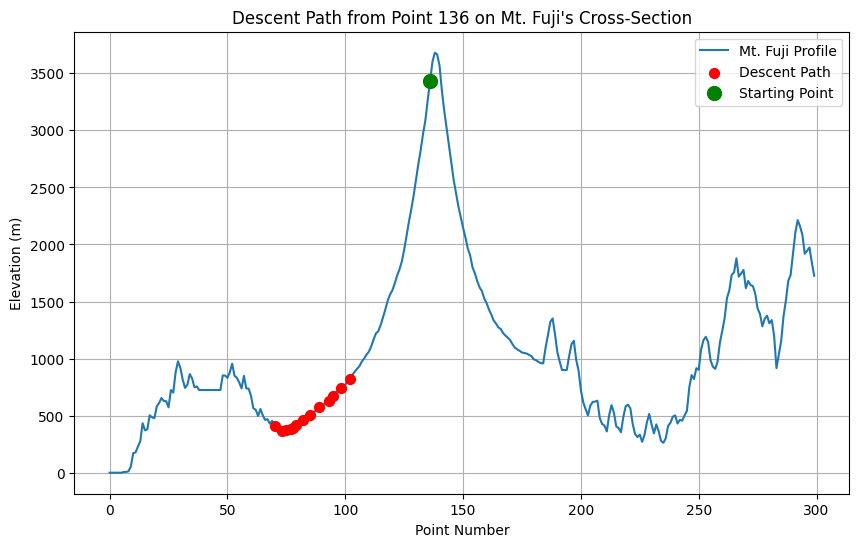

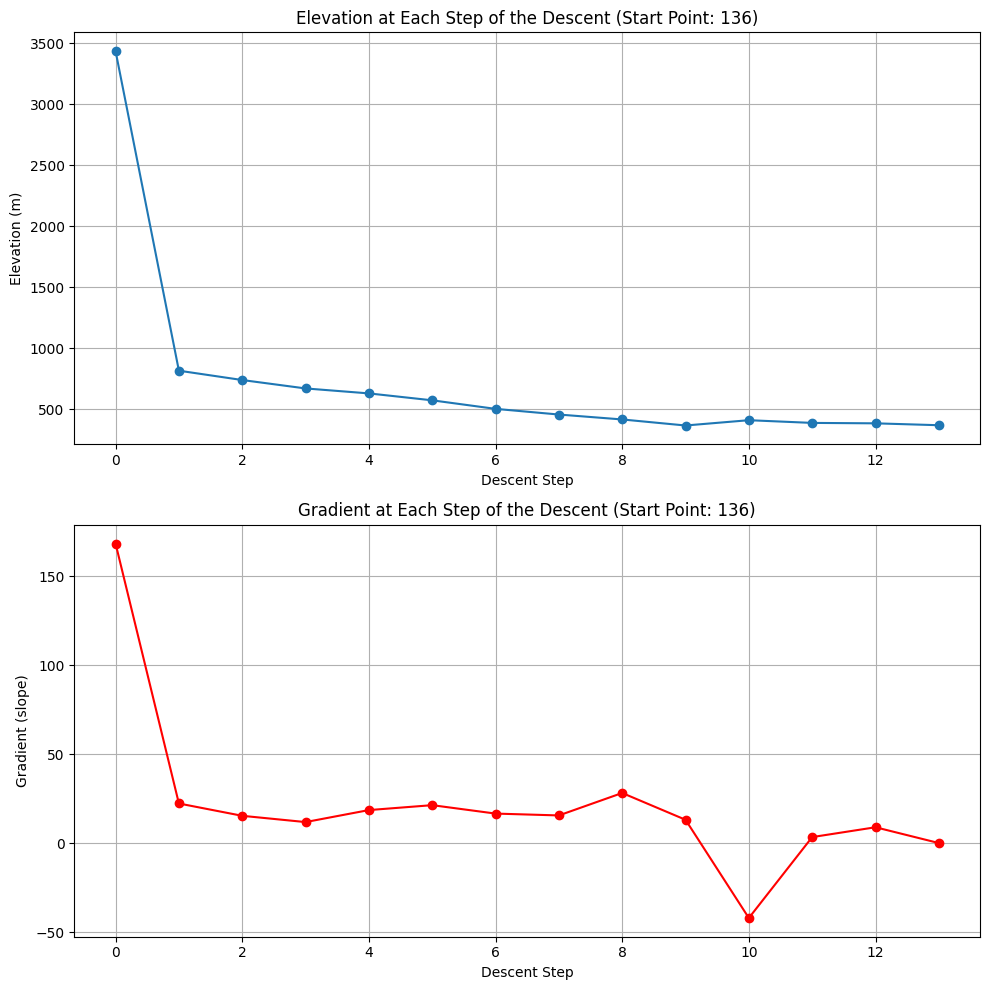


--- Running simulation starting from point 142 ---


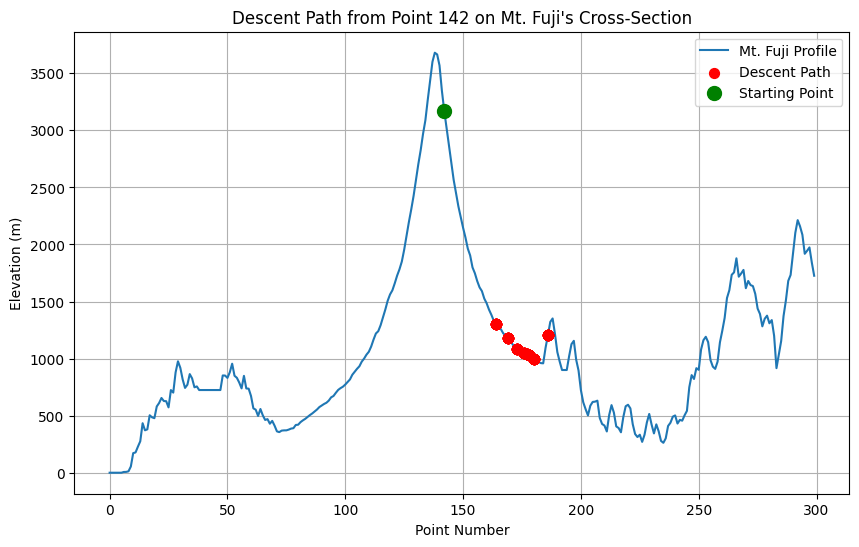

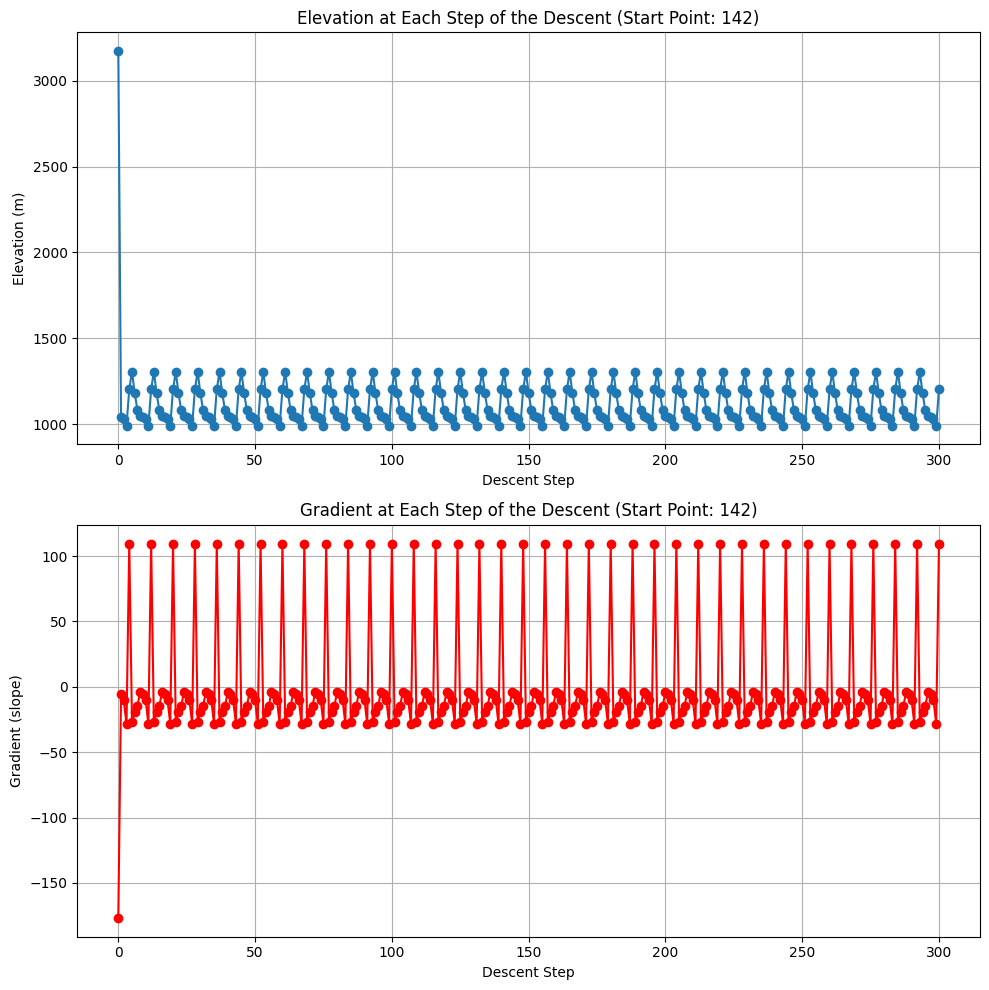


--- Running simulation starting from point 250 ---


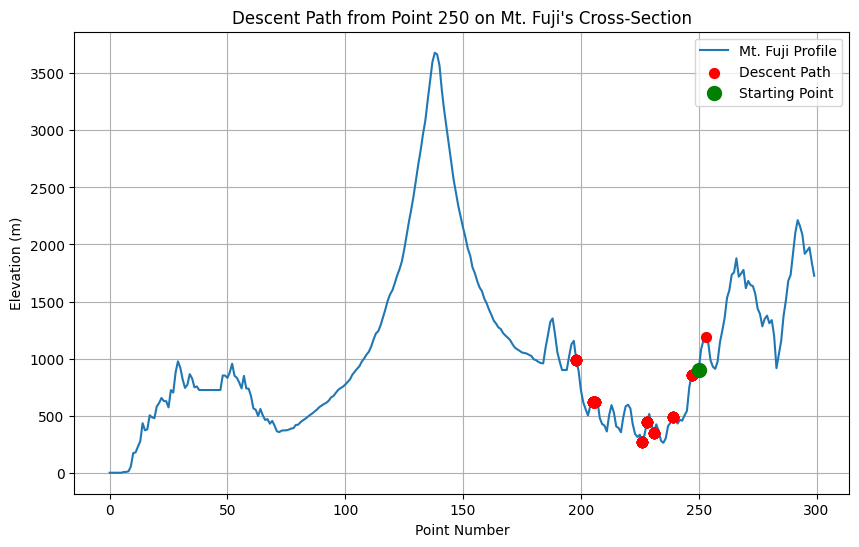

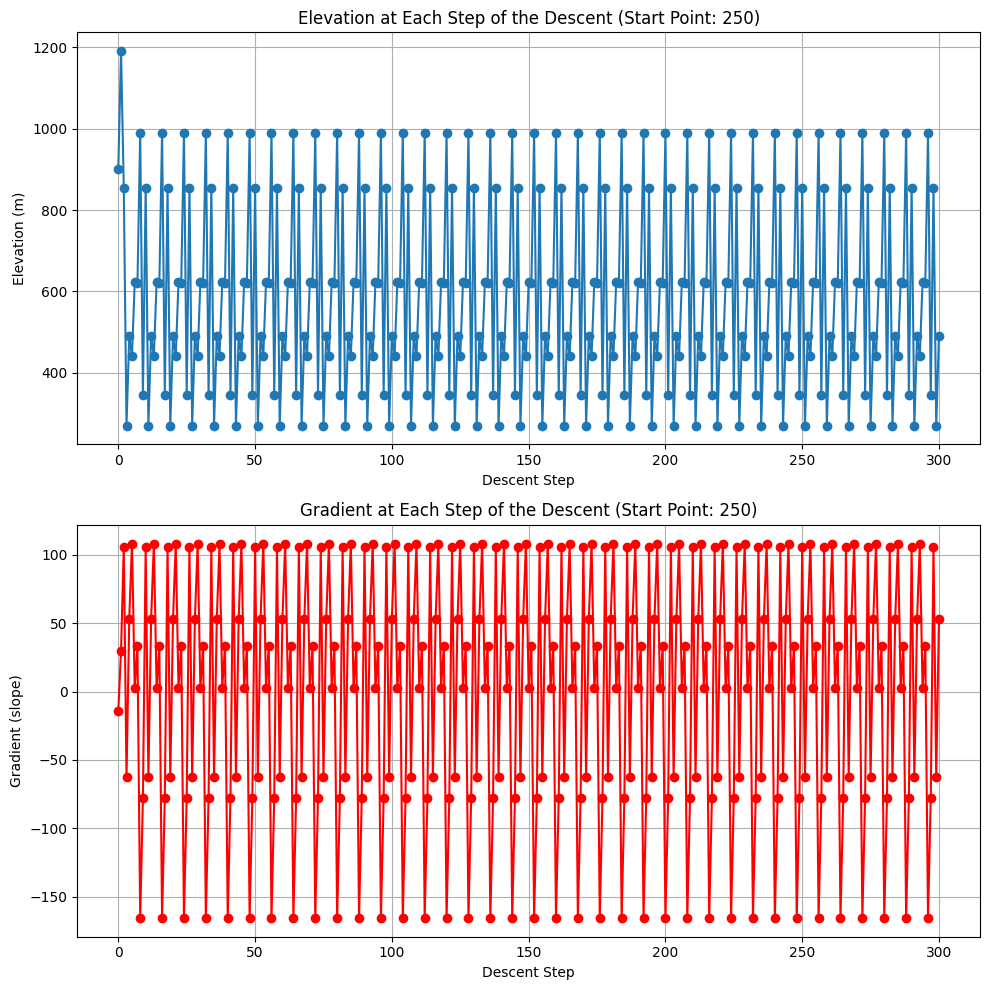

In [13]:
# This section demonstrates the effect of changing the starting point on the descent path.
# The code below is the solution to Problem 7.
start_points = [136, 142, 250]

for start_point in start_points:
    print(f"\n--- Running simulation starting from point {start_point} ---")
    run_descent_simulation(start_point=start_point)

In [ ]:
# [Problem 8] (Advance problem) Hyperparameter changes


--- Running simulation with alpha = 0.1 from start point 136 ---


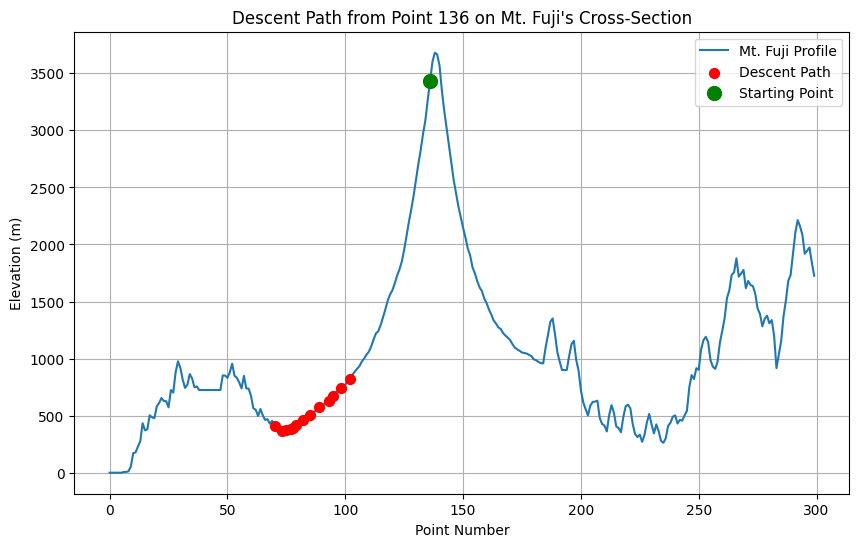

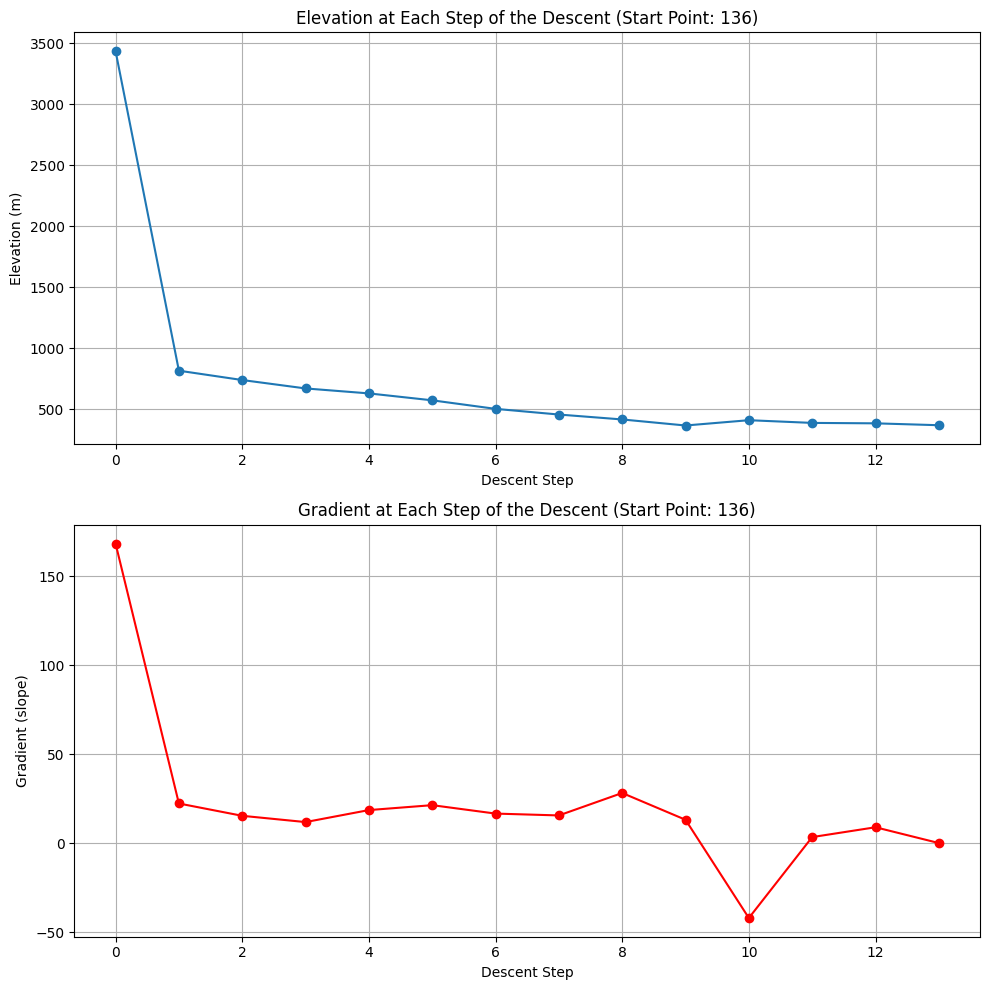


--- Running simulation with alpha = 0.2 from start point 136 ---


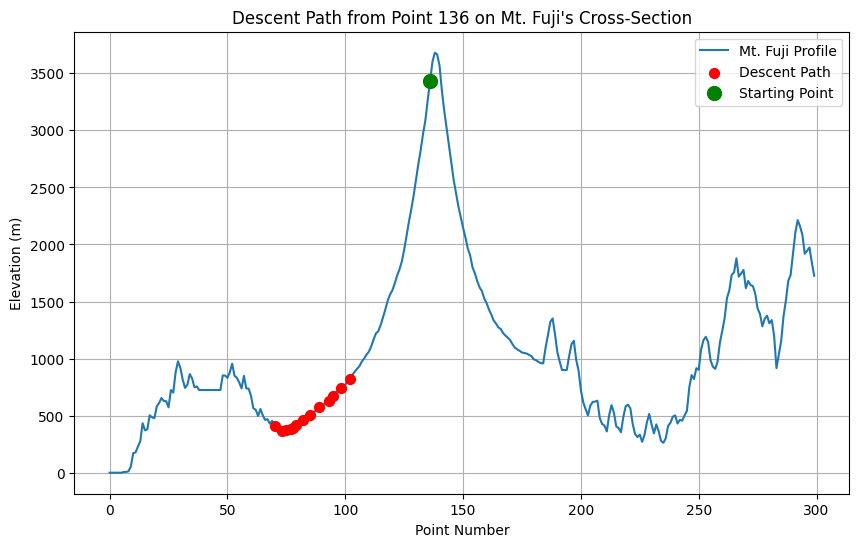

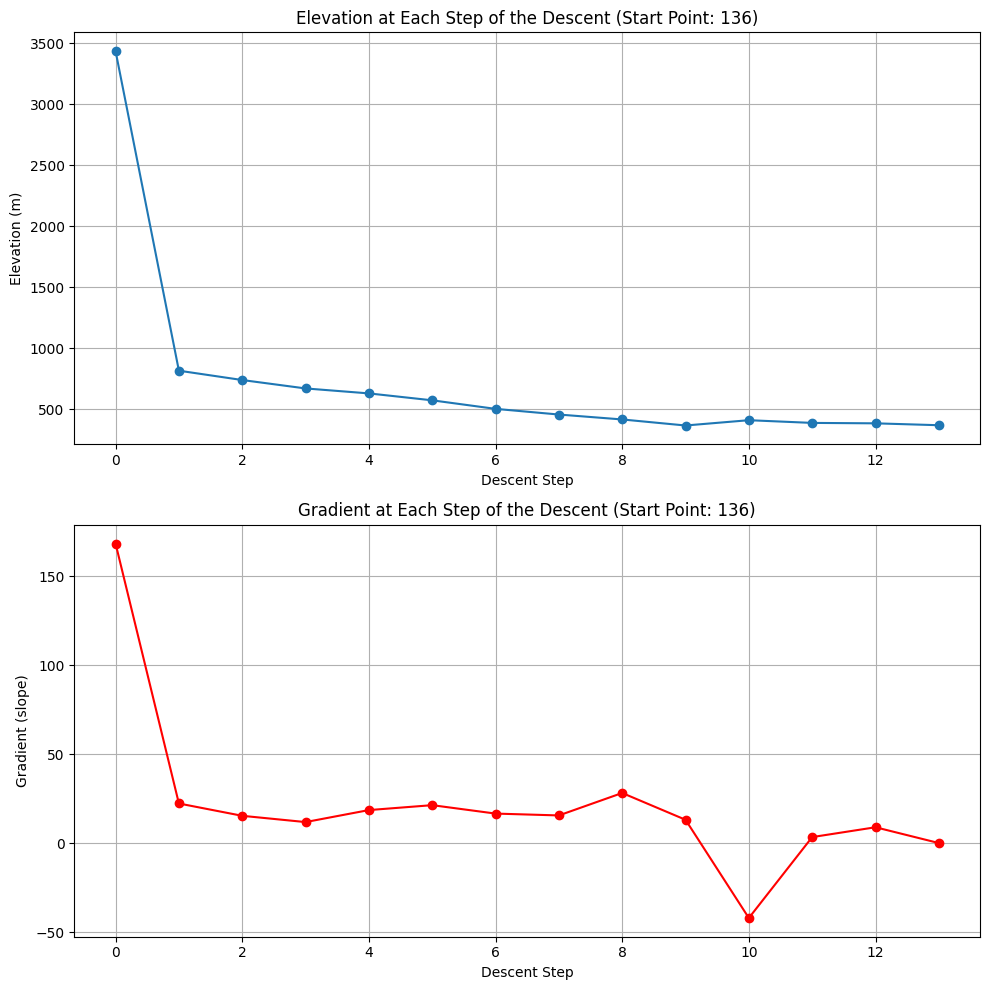


--- Running simulation with alpha = 0.5 from start point 136 ---


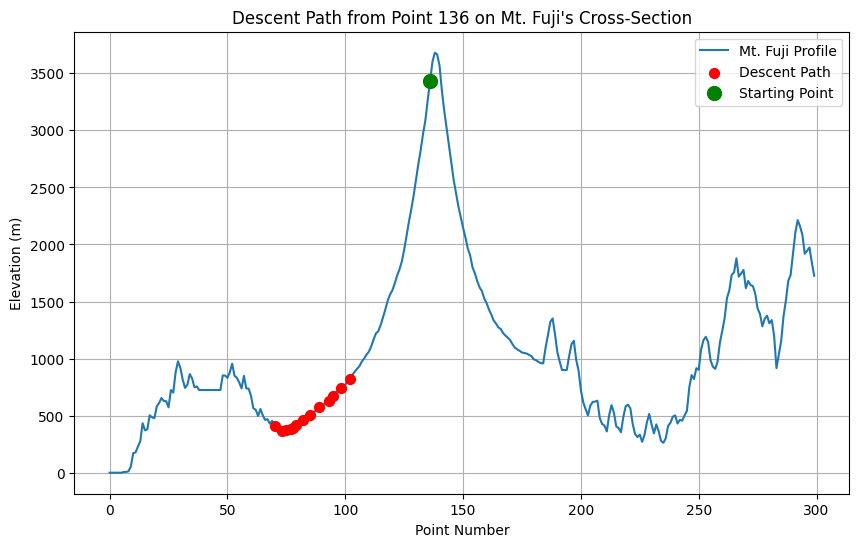

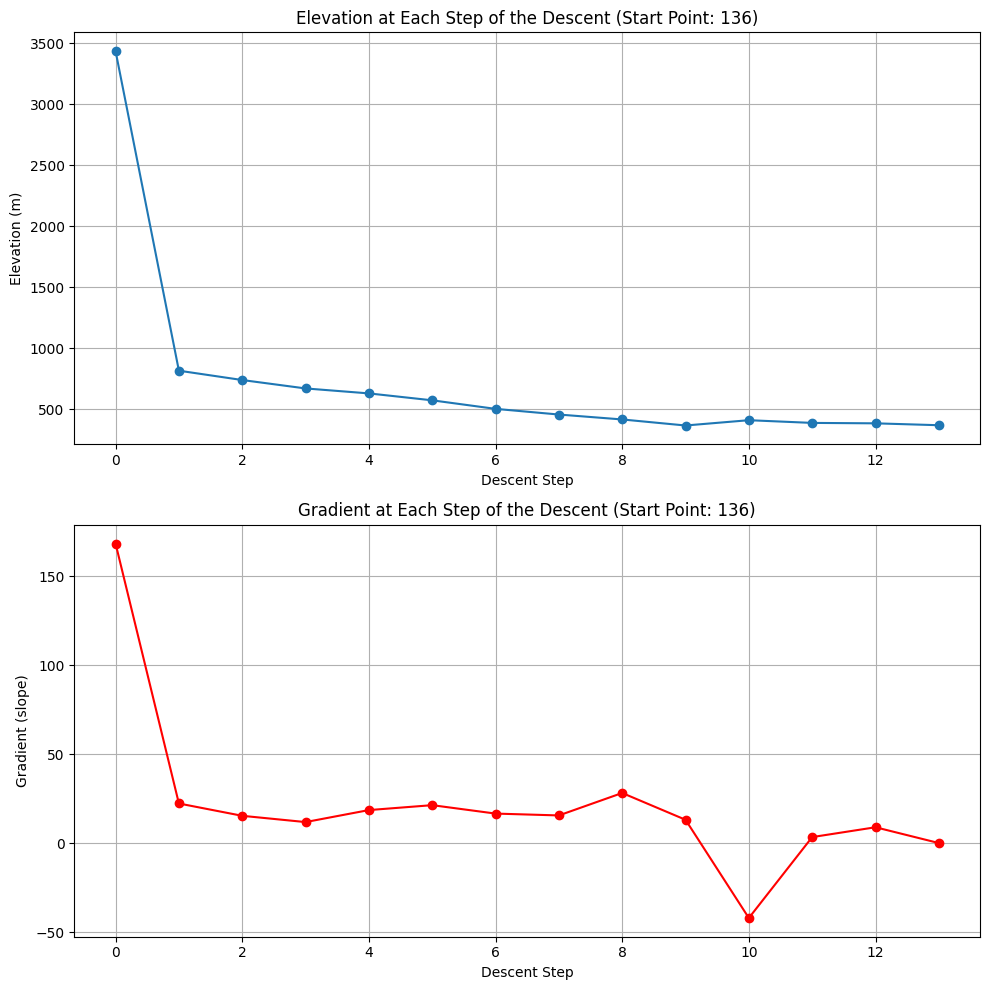


--- Running simulation with alpha = 0.1 from start point 142 ---


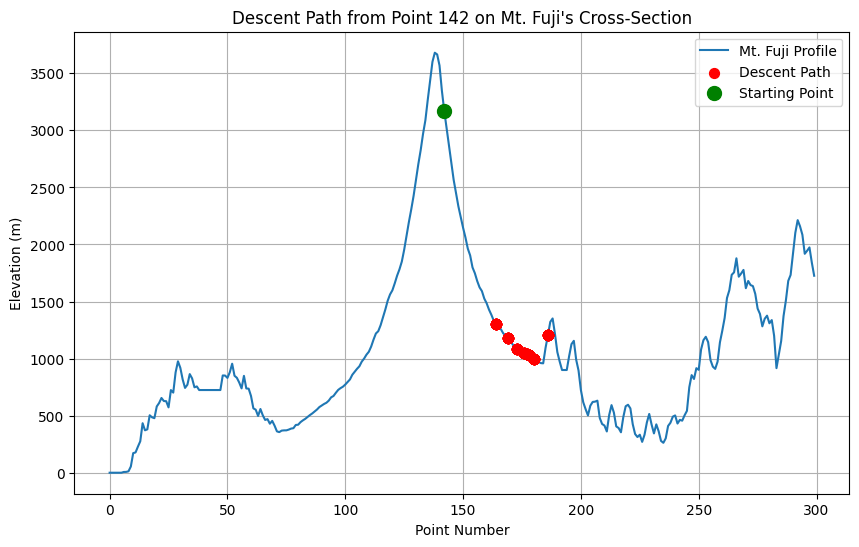

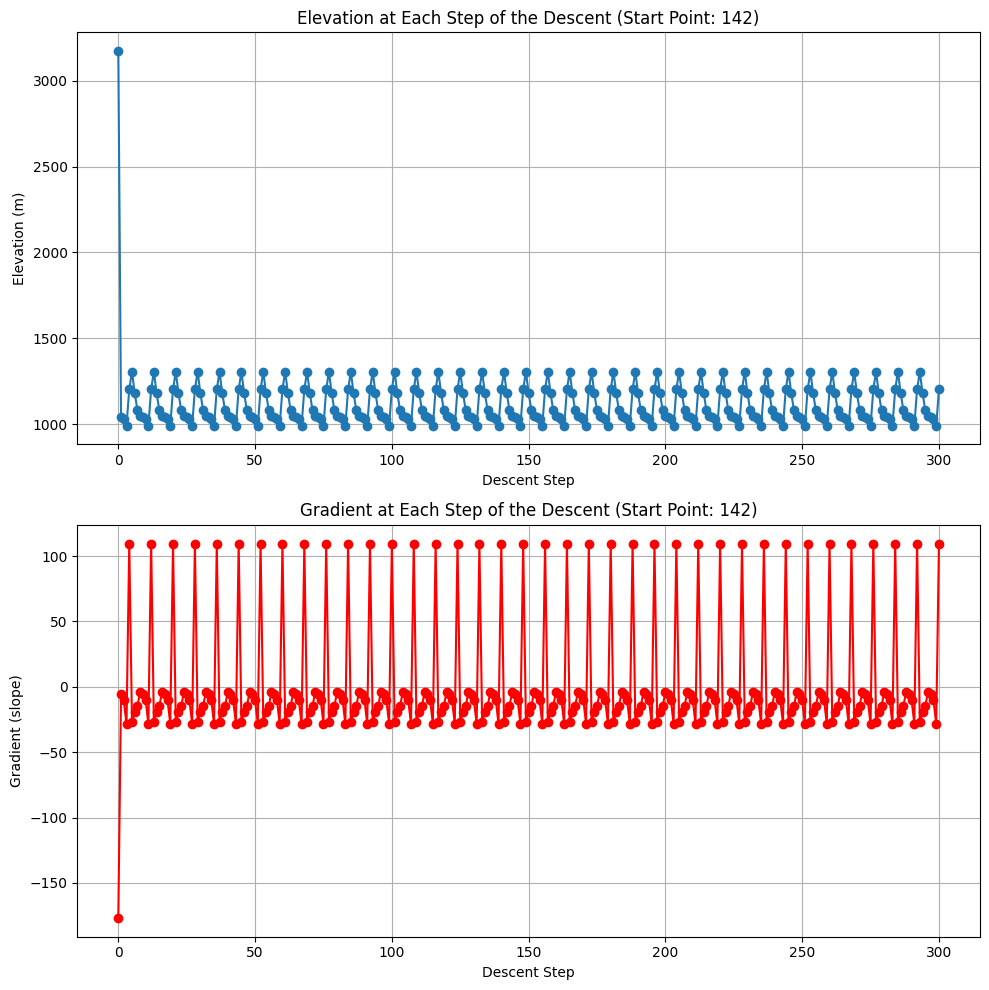


--- Running simulation with alpha = 0.5 from start point 142 ---


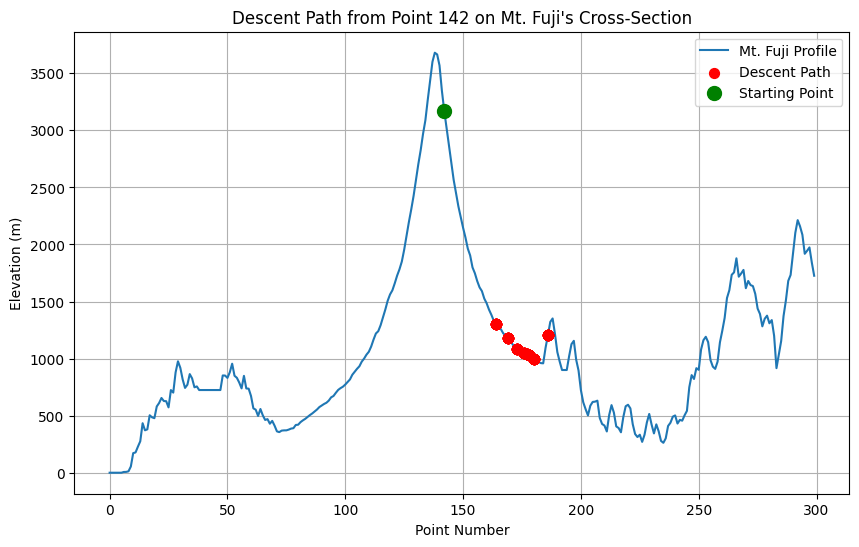

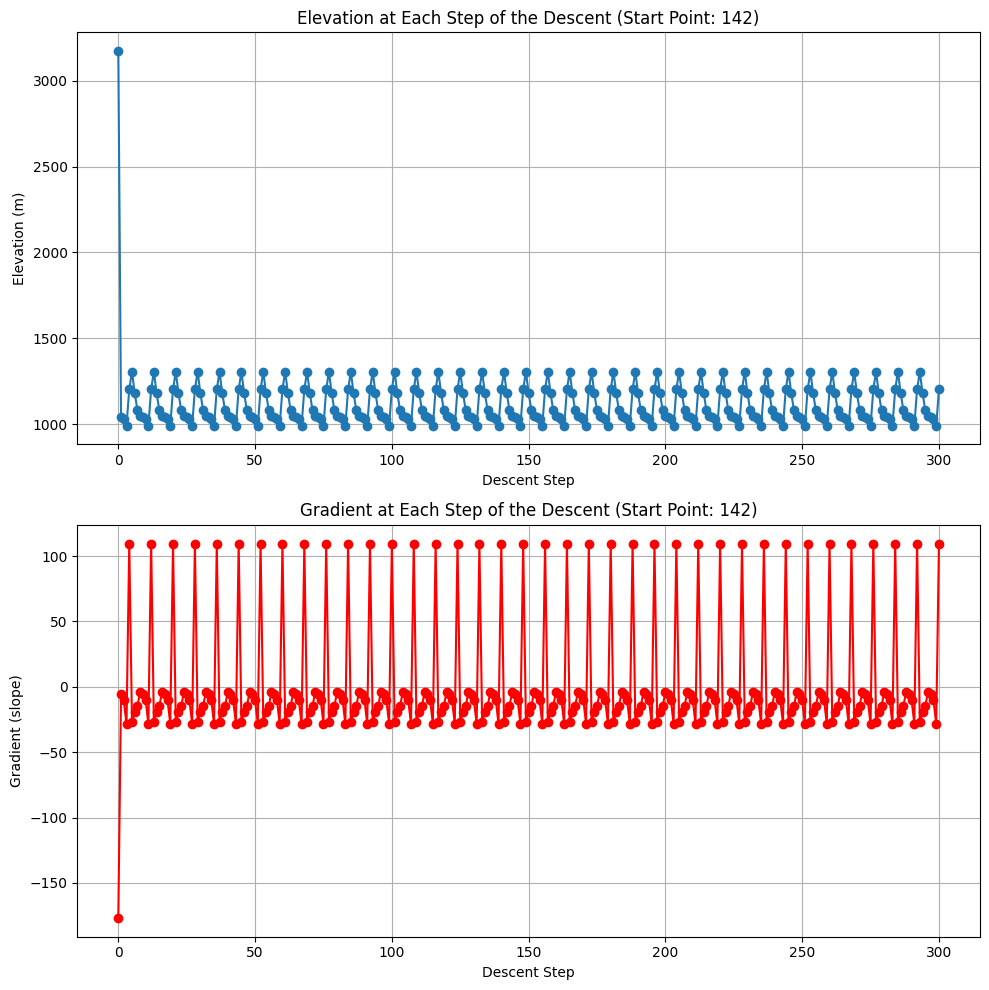

In [14]:
# This section demonstrates the effect of changing the learning rate (alpha)
# It visualizes the impact of the hyperparameter on the descent path.
start_point = 136  # We will use a single starting point to focus on alpha's effect
alphas = [0.1, 0.2, 0.5]  # A list of different alpha values to test

for alpha in alphas:
    print(f"\n--- Running simulation with alpha = {alpha} from start point {start_point} ---")
    run_descent_simulation(start_point=start_point, alpha=alpha)

# You can also combine different starting points and alphas to see combined effects.
# For example, to compare the descent from point 142 with different alphas:
start_point_2 = 142
alphas_2 = [0.1, 0.5]
for alpha in alphas_2:
    print(f"\n--- Running simulation with alpha = {alpha} from start point {start_point_2} ---")
    run_descent_simulation(start_point=start_point_2, alpha=alpha)